C:\Users\Nilavra Ghosh\AppData\Local\Temp\ipykernel_16644\3822158629.py:19: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, skiprows=header_idx, delim_whitespace=True)



--- Performance Parameters for MH60 ---
 alpha       CL     CL/CD  CL^1.5/CD        CM
   0.0 0.029331  4.997615   0.855906 -0.006438
   1.0 0.093597 15.326183   4.688835 -0.021432
   2.0 0.157791 21.456486   8.523142 -0.036427
   3.0 0.221859 23.822506  11.220856 -0.051405
   4.0 0.285749 23.858145  12.753490 -0.066351
   5.0 0.349408 22.799869  13.477172 -0.081246
   6.0 0.412784 21.312681  13.693028 -0.096073
   7.0 0.475825 19.756893  13.628318 -0.110815
   8.0 0.538482 18.298287  13.427527 -0.125454
   9.0 0.600703 16.966615  13.149980 -0.139973
  10.0 0.662440 15.761873  12.828654 -0.154356
  11.0 0.723644 14.684632  12.491816 -0.168588
  12.0 0.784269 13.725394  12.155066 -0.182652
  13.0 0.844268 12.869939  11.825422 -0.196533
  14.0 0.903597 12.112236  11.513615 -0.210214
  15.0 0.962213 11.418622  11.200807 -0.223686


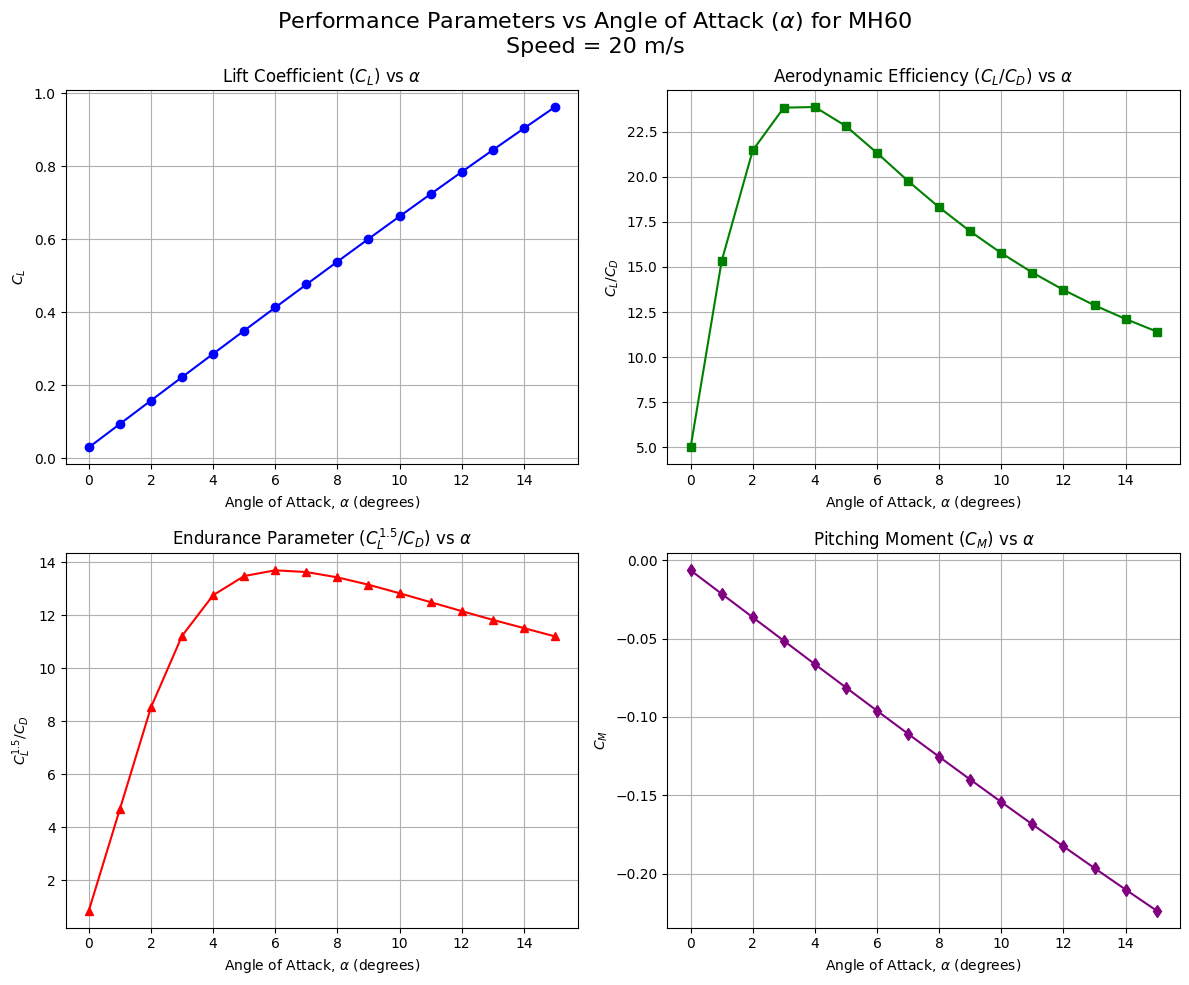

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
np.random.seed(2023102006)

def analyze_airfoil_data(file_path, airfoil_name):
    with open(file_path, 'r') as file:
        lines = file.readlines()
        
    header_idx = -1
    for i, line in enumerate(lines):
        if 'alpha' in line and 'CL' in line and 'CD' in line:
            header_idx = i
            break
            
    if header_idx == -1:
        raise ValueError(f"Could not find the data table in {file_path}. Check the file format.")

    df = pd.read_csv(file_path, skiprows=header_idx, delim_whitespace=True)

    df['CL/CD'] = df['CL'] / df['CD']
    df['CL^1.5/CD'] = (df['CL']**1.5) / df['CD']
    df.rename(columns={'Cm': 'CM'}, inplace=True)

    results_df = df[['alpha', 'CL', 'CL/CD', 'CL^1.5/CD', 'CM']].copy()

    print(f"\n--- Performance Parameters for {airfoil_name} ---")
    print(results_df.to_string(index=False))

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f'Performance Parameters vs Angle of Attack ($\\alpha$) for {airfoil_name}\nSpeed = 20 m/s', fontsize=16)

    axs[0, 0].plot(results_df['alpha'], results_df['CL'], marker='o', color='b', label='CL')
    axs[0, 0].set_title(r'Lift Coefficient ($C_L$) vs $\alpha$')
    axs[0, 0].set_xlabel(r'Angle of Attack, $\alpha$ (degrees)')
    axs[0, 0].set_ylabel(r'$C_L$')
    axs[0, 0].grid(True)

    axs[0, 1].plot(results_df['alpha'], results_df['CL/CD'], marker='s', color='g', label='CL/CD')
    axs[0, 1].set_title(r'Aerodynamic Efficiency ($C_L/C_D$) vs $\alpha$')
    axs[0, 1].set_xlabel(r'Angle of Attack, $\alpha$ (degrees)')
    axs[0, 1].set_ylabel(r'$C_L / C_D$')
    axs[0, 1].grid(True)

    axs[1, 0].plot(results_df['alpha'], results_df['CL^1.5/CD'], marker='^', color='r', label='CL^1.5/CD')
    axs[1, 0].set_title(r'Endurance Parameter ($C_L^{1.5}/C_D$) vs $\alpha$')
    axs[1, 0].set_xlabel(r'Angle of Attack, $\alpha$ (degrees)')
    axs[1, 0].set_ylabel(r'$C_L^{1.5} / C_D$')
    axs[1, 0].grid(True)

    axs[1, 1].plot(results_df['alpha'], results_df['CM'], marker='d', color='purple', label='CM')
    axs[1, 1].set_title(r'Pitching Moment ($C_M$) vs $\alpha$')
    axs[1, 1].set_xlabel(r'Angle of Attack, $\alpha$ (degrees)')
    axs[1, 1].set_ylabel(r'$C_M$')
    axs[1, 1].grid(True)

    plt.tight_layout()
    plt.subplots_adjust(top=0.90)
    plt.show()

FILE_PATH = 'MH60_T1-20_0 m_s-VLM1.txt'  
AIRFOIL_NAME = 'MH60'    

analyze_airfoil_data(FILE_PATH, AIRFOIL_NAME)